# A/B Testing — Bayes' Rule and False Discoveries

Scenario:

Historically:

- Only **10%** of experiments genuinely improve conversion.

A statistical test reports:

```text
p-value < 0.05
```

Assume:

- True improvements are detected **80%** of the time.
- False significance occurs **5%** of the time.

Question:

> What is the probability that your experiment genuinely improved conversion?

This is a Bayes' Rule problem because we are given:

$$P(\text{Significant} \mid \text{Real Improvement})$$

but we want:

$$P(\text{Real Improvement} \mid \text{Significant})$$


## Step 1: Define the Hypotheses

Let:

- `Improved` = experiment genuinely improves conversion
- `No Improvement` = experiment does not genuinely improve conversion

Evidence:

- `Significant` = statistical test reports `p-value < 0.05`


In [1]:
priors = {
    "Improved": 0.10,
    "No Improvement": 0.90,
}

likelihoods = {
    "Improved": 0.80,        # P(Significant | Improved)
    "No Improvement": 0.05,  # P(Significant | No Improvement)
}

priors, likelihoods

({'Improved': 0.1, 'No Improvement': 0.9},
 {'Improved': 0.8, 'No Improvement': 0.05})

## Step 2: Solve Analytically Using `explain_update()`

The evidence is:

```text
p-value < 0.05
```

So we update the prior probabilities using the likelihood of getting a significant result under each hypothesis.


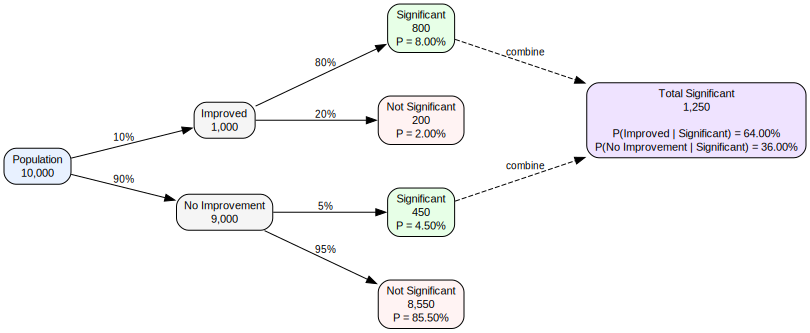

In [2]:
from probmodels import explain_update

result = explain_update(
    priors=priors,
    likelihoods=likelihoods,
    population_size=10_000,
    evidence_name="Significant",
    no_evidence_name="Not Significant",
    draw_tree=True,
    edge_label_style="short",
    show_joint_probabilities=True,
    show_posterior_node=True,
)

result["tree"]

In [3]:
result["posteriors"]

{'Improved': 0.64, 'No Improvement': 0.36}

## Step 3: Interpret with Counts

Using 10,000 experiments:

- Real improvements: 1,000
- Significant results among real improvements: 800
- No real improvement: 9,000
- False significant results: 450

So among all significant experiments:

```text
800 are real improvements
450 are false significant results
```

The posterior probability is:

$$
P(\text{Improved} \mid \text{Significant})
=
\frac{800}{800 + 450}
$$


In [4]:
result["counts"]

{'Improved': {'hypothesis_count': 1000,
  'evidence_count': 800,
  'no_evidence_count': 200},
 'No Improvement': {'hypothesis_count': 9000,
  'evidence_count': 450,
  'no_evidence_count': 8550}}

In [5]:
p_improved_given_significant = result["posteriors"]["Improved"]

print(f"P(Improved | Significant) = {p_improved_given_significant:.4f}")
print(f"P(Improved | Significant) = {p_improved_given_significant:.2%}")

P(Improved | Significant) = 0.6400
P(Improved | Significant) = 64.00%


## Step 4: Verify Using `simulate_bayes()`

Now simulate many A/B experiments and estimate the same posterior probability.


In [6]:
from probmodels import simulate_bayes

sim_result = simulate_bayes(
    priors=priors,
    likelihoods=likelihoods,
    n=1_000_000,
    hypothesis_name="Experiment Reality",
    evidence_name="Significant",
    seed=42,
)

sim_result["table"]

Experiment Reality,Improved,No Improvement,All
Significant,,,
False,20070,855365,875435
True,79644,44921,124565
All,99714,900286,1000000


In [7]:
sim_result["posterior_exact"]

{'Improved': 0.64, 'No Improvement': 0.36}

In [10]:
sim_result["posterior_explanations"]["Improved"]

'P(Improved | Significant) = 0.6400'

## Step 5: Compare Exact vs Simulated Results

In [11]:
import pandas as pd

comparison = pd.DataFrame(
    {
        "Exact": sim_result["posterior_exact"],
        "Simulated": sim_result["posterior_simulated"],
    }
)

comparison

,Exact,Simulated
Improved,0.64,0.639377
No Improvement,0.36,0.360623


## Step 6: Why This Matters

A p-value below 0.05 does **not** mean:

```text
There is a 95% chance the experiment improved conversion.
```

Instead, it means:

```text
If there were no real improvement, this kind of significant result would occur 5% of the time.
```

Bayes' Rule answers the decision-making question:

> Given that the test was significant, how likely is a real improvement?


## Final Answer

The probability that the experiment genuinely improved conversion is:

$$
P(\text{Improved} \mid \text{Significant})
=
\frac{0.80 \times 0.10}
{(0.80 \times 0.10) + (0.05 \times 0.90)}
$$

$$
=
\frac{0.08}{0.125}
=
0.64
$$

So:

```text
P(Improved | Significant) = 64%
```

A statistically significant result is meaningful, but not definitive.


## Key Takeaways

1. This is a Bayes' Rule problem.
2. The prior probability of real improvement matters.
3. Statistical significance is evidence, not certainty.
4. False positives can be common when most experiments do not truly improve conversion.
5. In this scenario, a significant result has a **64%** chance of reflecting a genuine improvement.
